In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

LOAD THE DATASET

In [41]:
df=pd.read_csv(r'C:\Users\Welcome\Downloads\archive (1) (1).csv')

BASIC OPERATION TO UNDERSTAND THE DATASET

In [42]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [43]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [44]:
df.describe()


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [45]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

HANDLE THE MISSING AND CATAGERICAL FEATURES

In [46]:
df.replace('?',np.nan, inplace=True)

In [47]:
df.drop(columns=["weight", "payer_code"], inplace=True)

In [48]:
print(df.race)

0               Caucasian
1               Caucasian
2         AfricanAmerican
3               Caucasian
4               Caucasian
               ...       
101761    AfricanAmerican
101762    AfricanAmerican
101763          Caucasian
101764          Caucasian
101765          Caucasian
Name: race, Length: 101766, dtype: object


In [49]:
df["race"].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: race, Length: 101766, dtype: bool

In [50]:
df["race"].fillna("Unknown", inplace=True)
df["medical_specialty"].fillna("Unknown", inplace=True)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_10844\1288903122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["race"].fillna("Unknown", inplace=True)
C:\Users\Welcome\AppData\Local\Temp\ipykernel_10844\1288903122.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [51]:
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)

In [52]:

df['readmit_30'] = df['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

CHECKING FOR THE OUTLIER USING THE BOXPLOT

<Axes: >

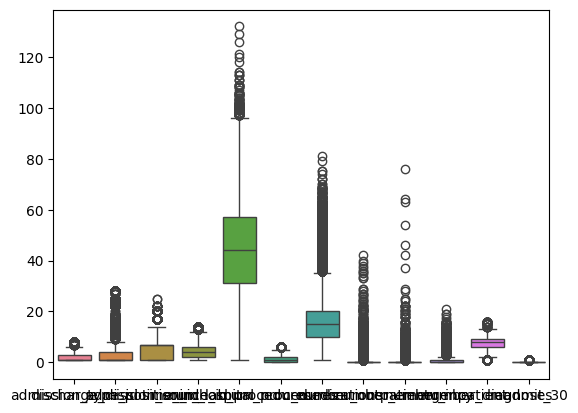

In [53]:
sns.boxplot(data=df.select_dtypes(['int64','float']))

In [54]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'readmit_30'],
      dtype='object')

HANDLING HE OUTLIER USING THE IQR

In [55]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)


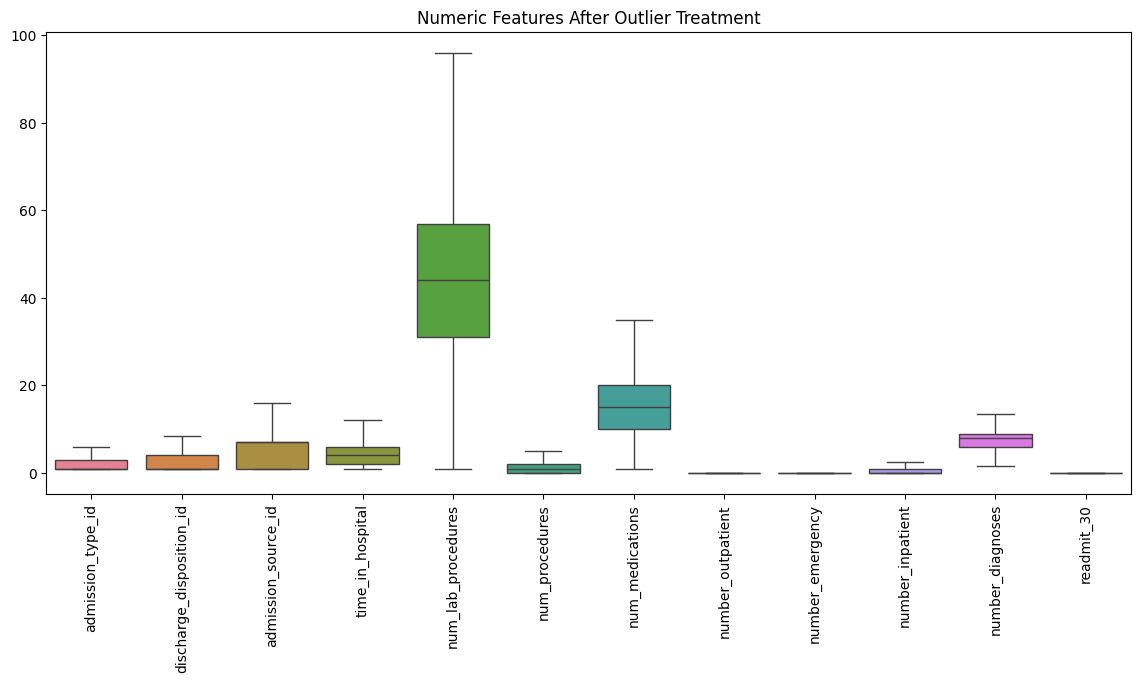

In [56]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Numeric Features After Outlier Treatment")
plt.show()


In [57]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})
df["insulin"] = df["insulin"].map({"Yes": 1, "No": 0})

In [58]:
categorical_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "A1Cresult"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [59]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isna().sum().sum())
print(df.head())

Final dataset shape: (101766, 71)
Total missing values: 152608
              race  gender      age  time_in_hospital  \
0        Caucasian     0.0   [0-10)                 1   
1        Caucasian     0.0  [10-20)                 3   
2  AfricanAmerican     0.0  [20-30)                 2   
3        Caucasian     1.0  [30-40)                 2   
4        Caucasian     1.0  [40-50)                 1   

          medical_specialty  num_lab_procedures  num_procedures  \
0  Pediatrics-Endocrinology                  41               0   
1                   Unknown                  59               0   
2                   Unknown                  11               5   
3                   Unknown                  44               1   
4                   Unknown                  51               0   

   num_medications  number_outpatient  number_emergency  ...  \
0                1                  0                 0  ...   
1               18                  0                 0  ...   

In [60]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols


Index(['gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'insulin', 'diabetesMed',
       'readmit_30'],
      dtype='object')

In [61]:
from scipy.stats import zscore
z_scores = df[num_cols].apply(zscore)
z_scores.head()


,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,diabetesMed,readmit_30
0,NaN,-1.163010,-0.106226,-0.816151,-2.002068,NaN,NaN,-0.633137,-3.076064,NaN,-1.829868,NaN
1,NaN,-0.471487,0.809860,-0.816151,0.296283,NaN,NaN,-0.633137,0.819400,NaN,0.546488,NaN
2,NaN,-0.817248,-1.633035,2.344652,-0.379703,NaN,NaN,0.599406,-0.738786,NaN,0.546488,NaN
3,NaN,-0.817248,0.046455,-0.183990,0.025889,NaN,NaN,-0.633137,-0.219390,NaN,0.546488,NaN
4,NaN,-1.163010,0.402711,-0.816151,-1.055688,NaN,NaN,-0.633137,-1.258181,NaN,0.546488,NaN


In [62]:
outliers = (z_scores.abs() > 3)
outliers.sum().sort_values(ascending=False)


number_diagnoses      281
gender                  0
num_lab_procedures      0
time_in_hospital        0
num_procedures          0
num_medications         0
number_emergency        0
number_outpatient       0
number_inpatient        0
insulin                 0
diabetesMed             0
readmit_30              0
dtype: int64

In [63]:
outlier_rows = outliers.any(axis=1).sum()
outlier_rows


np.int64(281)

In [64]:

Q1 = df['number_diagnoses'].quantile(0.25)
Q3 = df['number_diagnoses'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['number_diagnoses'] = df['number_diagnoses'].clip(lower, upper)


In [65]:
print(df.columns)

Index(['race', 'gender', 'age', 'time_in_hospital', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'readmit_30', 'admission_type_id_2', 'admission_type_id_3',
       'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_6',
       'discharge_disposition_id_2.0', 'discharge_disposition_id_3.0',
       'discharge_disposition_id

In [66]:
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                'num_medications', 'number_outpatient', 'number_emergency', 
                'number_inpatient', 'number_diagnoses']
df_numeric = df[numeric_cols + ['readmit_30']]

In [67]:
df.groupby('readmit_30')[
    ['time_in_hospital',
     'num_medications',
     'number_inpatient',
     'number_emergency']
].mean()

,time_in_hospital,num_medications,number_inpatient,number_emergency
readmit_30,,,,
0,4.317424,15.699499,0.471104,0.0
1,4.731355,16.676323,0.852646,0.0


VISUALIZATION 

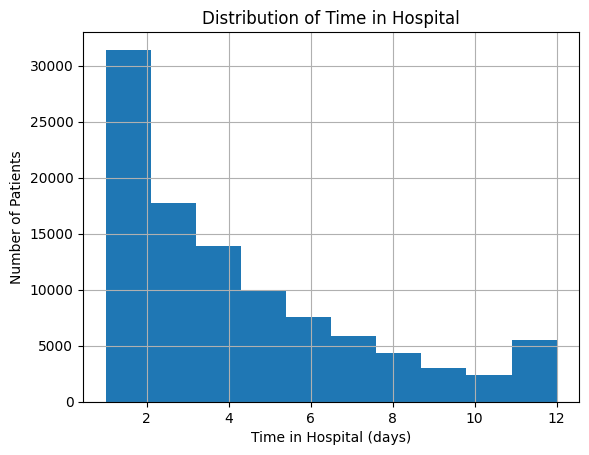

In [68]:

df["time_in_hospital"].hist()
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Time in Hospital")
plt.show()

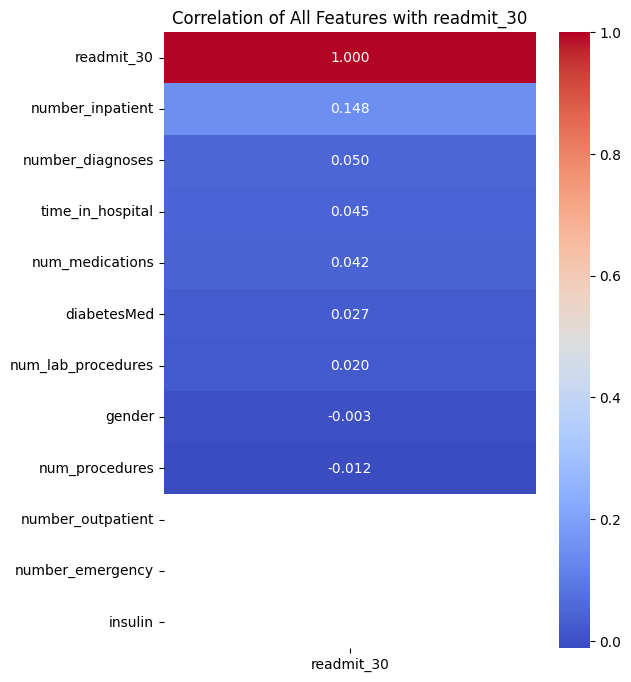

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Calculate correlation with readmit_30
corr_with_target = numeric_df.corr()[['readmit_30']].sort_values(by='readmit_30', ascending=False)

# Plot heatmap
plt.figure(figsize=(6,8))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', fmt=".3f")

plt.title("Correlation of All Features with readmit_30")
plt.show()

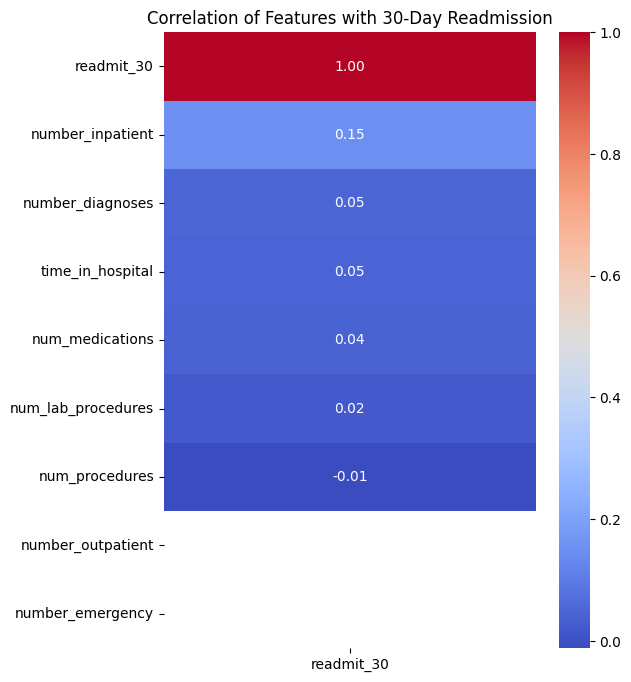

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation with readmit_30
corr_readmit = df_numeric.corr()[['readmit_30']].sort_values(by='readmit_30', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_readmit, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation of Features with 30-Day Readmission")
plt.show()

=== BIVARIATE ANALYSIS: DIABETIC READMISSION PATTERNS ===



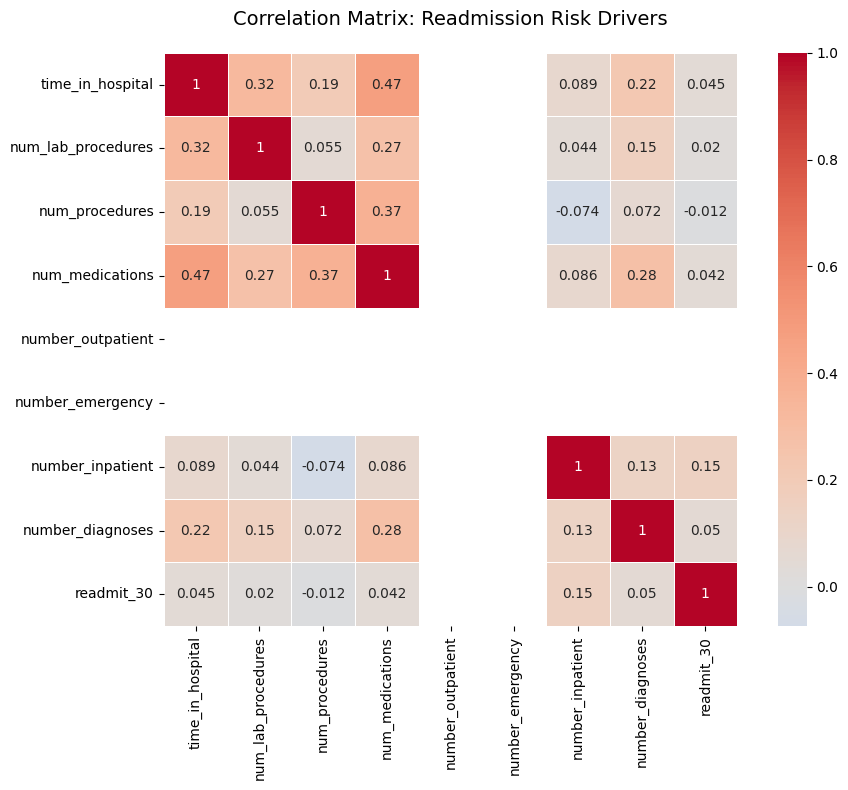

In [71]:
print("=== BIVARIATE ANALYSIS: DIABETIC READMISSION PATTERNS ===\n")

plt.figure(figsize=(10,8))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Readmission Risk Drivers', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [72]:
df.groupby('readmit_30')['number_emergency'].mean()

readmit_30
0    0.0
1    0.0
Name: number_emergency, dtype: float64

In [73]:
df.groupby('readmit_30')['num_medications'].mean()

readmit_30
0    15.699499
1    16.676323
Name: num_medications, dtype: float64

In [74]:
df.groupby('readmit_30')['time_in_hospital'].mean()

readmit_30
0    4.317424
1    4.731355
Name: time_in_hospital, dtype: float64

In [75]:
df.groupby('readmit_30')['number_inpatient'].mean()

readmit_30
0    0.471104
1    0.852646
Name: number_inpatient, dtype: float64

<Axes: xlabel='time_in_hospital', ylabel='Count'>

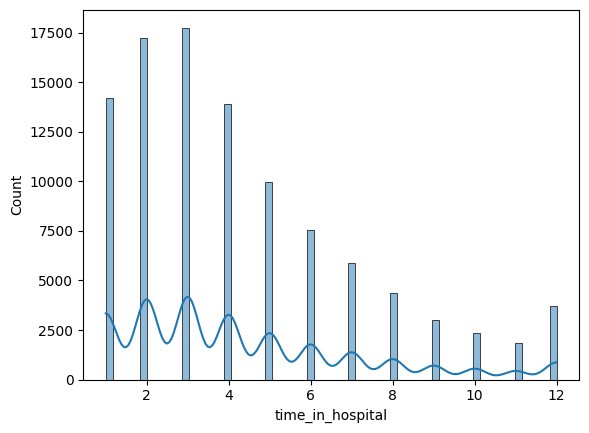

In [78]:
sns.histplot(df['time_in_hospital'], kde=True) 


      

<Axes: xlabel='num_medications', ylabel='Count'>

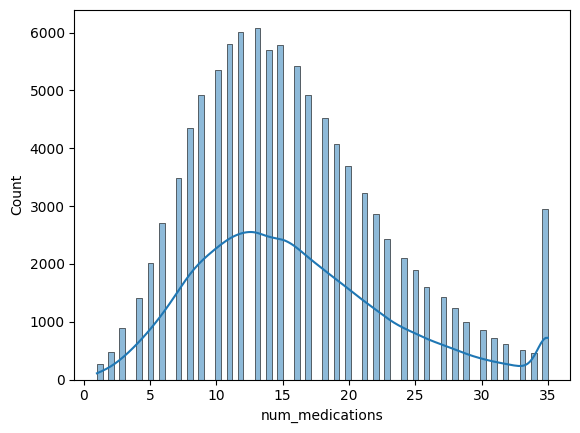

In [ ]:
sns.histplot(df['num_medications'], kde=True)


<Axes: xlabel='number_inpatient', ylabel='Count'>

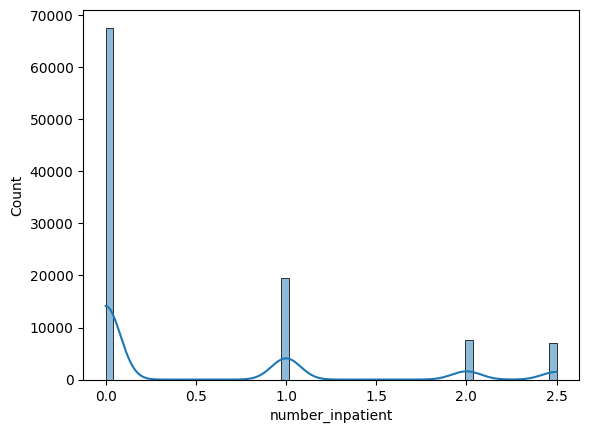

In [ ]:
sns.histplot(df['number_inpatient'], kde=True)

In [ ]:
df['readmit_30'].value_counts()


readmit_30
0    90409
1    11357
Name: count, dtype: int64

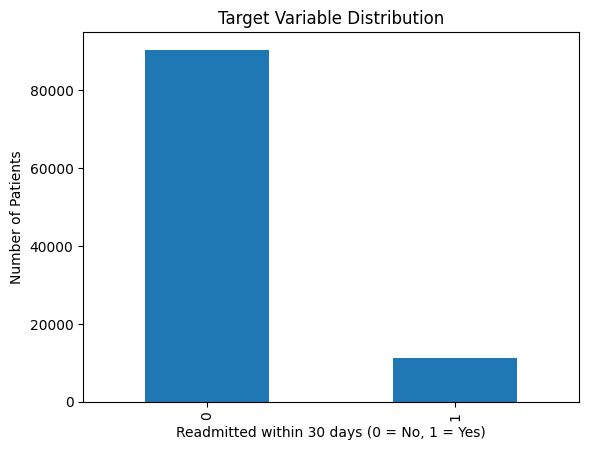

In [ ]:
df['readmit_30'].value_counts().plot(kind='bar')
plt.xlabel("Readmitted within 30 days (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("Target Variable Distribution")
plt.show()

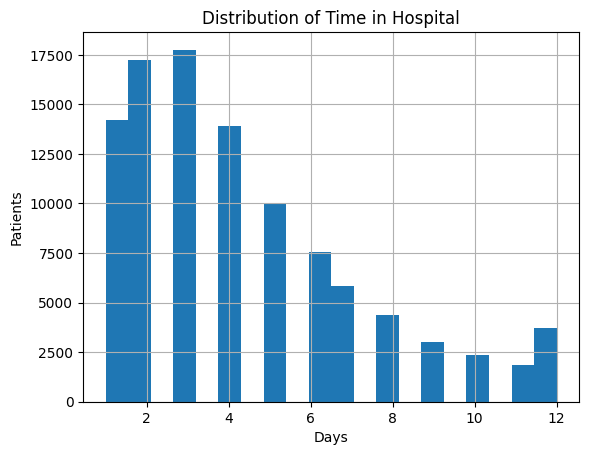

In [ ]:
df['time_in_hospital'].hist(bins=20)
plt.xlabel("Days")
plt.ylabel("Patients")
plt.title("Distribution of Time in Hospital")
plt.show()

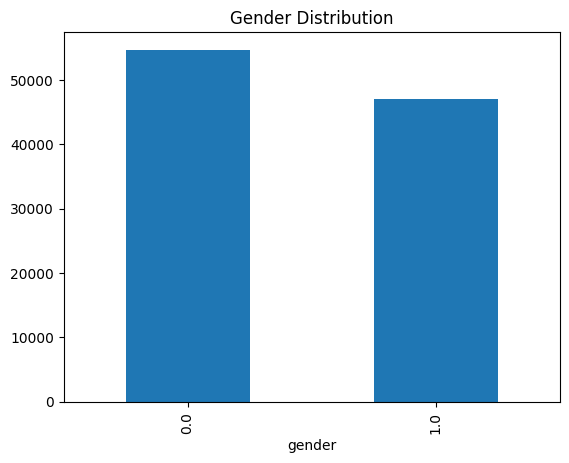

In [ ]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

In [81]:
pd.crosstab(df['gender'], df['readmit_30'], normalize='index')

readmit_30,0,1
gender,,
0.0,0.887548,0.112452
1.0,0.889385,0.110615


In [83]:
df.select_dtypes(include='object').columns

Index(['race', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'readmitted'],
      dtype='object')

In [84]:
df = df.drop(columns=['readmitted'])

In [85]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 70 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   race                          101766 non-null  int64  
 1   gender                        101763 non-null  float64
 2   age                           101766 non-null  int64  
 3   time_in_hospital              101766 non-null  int64  
 4   medical_specialty             101766 non-null  int64  
 5   num_lab_procedures            101766 non-null  int64  
 6   num_procedures                101766 non-null  int64  
 7   num_medications               101766 non-null  int64  
 8   number_outpatient             101766 non-null  int64  
 9   number_emergency              101766 non-null  int64  
 10  number_inpatient              101766 non-null  float64
 11  diag_1                        101766 non-null  int64  
 12  diag_2                        101766 non-nul

In [87]:
corr = df.corr()[['readmit_30']].sort_values(by='readmit_30', ascending=False)

In [88]:
print(corr)

                              readmit_30
readmit_30                      1.000000
number_inpatient                0.148074
number_diagnoses                0.049662
time_in_hospital                0.045065
discharge_disposition_id_3.0    0.044343
...                                  ...
number_outpatient                    NaN
number_emergency                     NaN
examide                              NaN
citoglipton                          NaN
insulin                              NaN

[70 rows x 1 columns]


THE CORRELATION BETWEEN READMIT_30 AND ALL FEATURES IN THE DATASETS

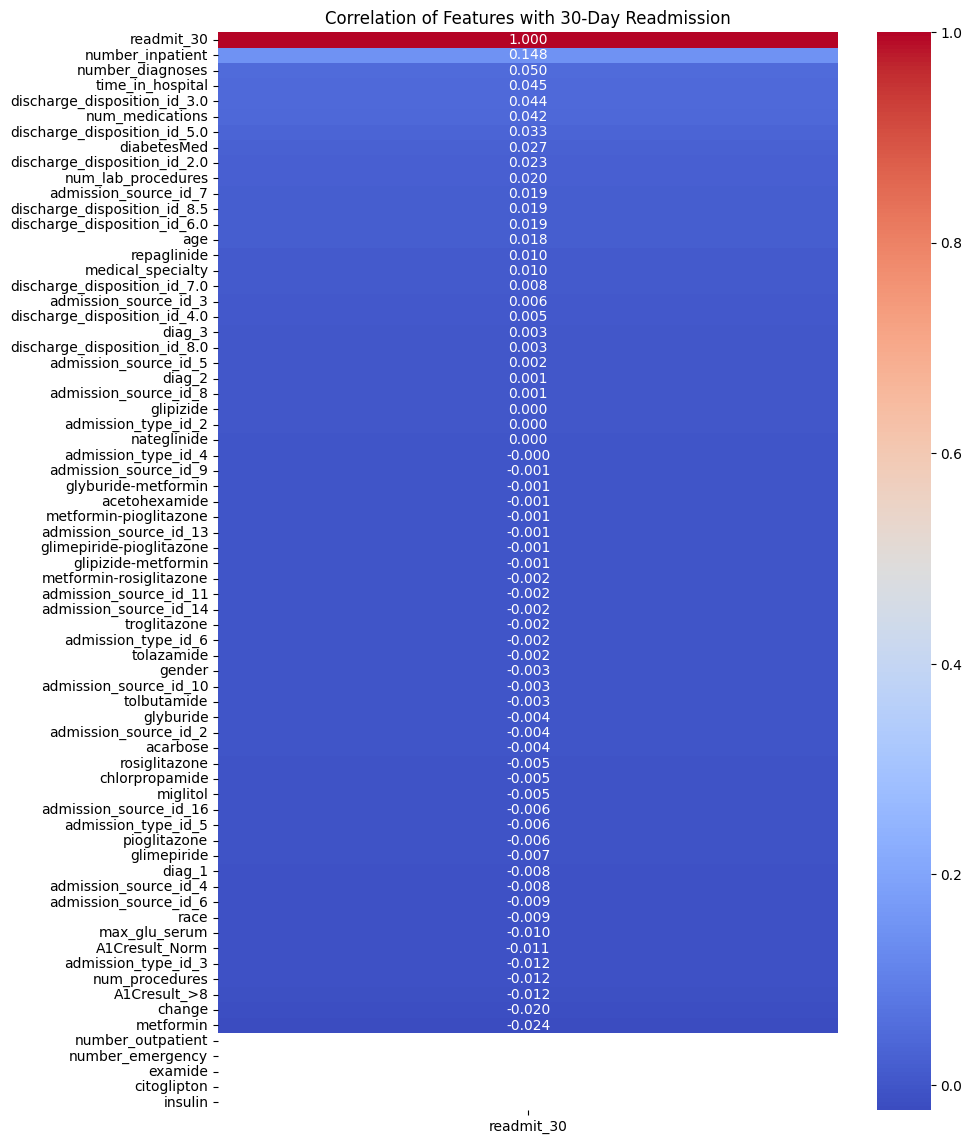

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,14))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".3f")

plt.title("Correlation of Features with 30-Day Readmission")
plt.show()